In [5]:
# CÉLULA 1: Importação de bibliotecas e geração do sinal acústico simulado
import numpy as np  # Biblioteca para cálculos matemáticos e geração de vetores
import scipy.signal as signal  # Módulo para filtragem e processamento digital de sinais
from scipy.fftpack import dct  # Função para Transformada Discreta do Cosseno
import matplotlib.pyplot as plt  # Biblioteca para geração de gráficos
import librosa  # Biblioteca padrão para carregamento e manipulação de áudios
import os

# 1. Definição dos parâmetros globais do sinal
sr = 8000  # Taxa de amostragem em 8000 Hz, padrão das boias da RVT
duracao = 2.0  # Janela temporal de análise em 2,0 segundos
t = np.linspace(0, duracao, int(sr * duracao), endpoint=False)  # Vetor de tempo com 16.000 amostras

# 2. Simulação do sinal acústico do hidrofone (pulso de impacto + ruído marinho)
f_central = 300  # Frequência central do impacto do splash em 300 Hz
pulso = np.sin(2 * np.pi * f_central * t) * np.exp(-15 * t)  # Pulso senoidal com decaimento exponencial
ruido_fundo = np.random.normal(0, 0.05, len(t))  # Ruído gaussiano do ambiente marinho
sinal_bruto = pulso + ruido_fundo  # Sinal resultante da recepção do sensor

print("Célula 1 executada com sucesso! Tamanho do sinal:", len(sinal_bruto))

Célula 1 executada com sucesso! Tamanho do sinal: 16000


In [6]:
# CÉLULA 2: Pré-processamento e extração do vetor combinado [MFCC + SDF]

# 1. Remoção do offset DC (subtrai a média) e filtragem FIR de pré-ênfase
sinal_dc = sinal_bruto - np.mean(sinal_bruto)  # Subtrai a média para centralizar a amplitude em zero
sinal_pre = signal.lfilter([1, -0.97], 1, sinal_dc)  # Filtro FIR de pré-ênfase para realçar altas frequências

# 2. Enquadramento (Framing) e Janelamento de Hamming
tam_frame = 512  # Quadros de 512 amostras (64 ms a 8 kHz)
passo = 256  # Passo entre quadros para 50% de sobreposição
n_frames = (len(sinal_pre) - tam_frame) // passo + 1  # Total de quadros no segmento de 2 segundos

quadros = np.array([sinal_pre[i * passo : i * passo + tam_frame] for i in range(n_frames)])  # Fatiamento em matriz
quadros_janelados = quadros * np.hamming(tam_frame)  # Aplicação da janela de Hamming

# 3. Análise Espectral via FFT
espectro_potencia = (np.abs(np.fft.rfft(quadros_janelados, axis=1)) ** 2) / tam_frame  # Densidade espectral de potência

# 4. Projeção no Banco de 42 Filtros Mel Customizados
n_filtros = 42  # Quantidade de filtros triangulares passa-banda
mels = np.linspace(0, 2595 * np.log10(1 + 3500 / 700), n_filtros + 2)  # Distribuição linear na escala Mel
hz = 700 * (10 ** (mels / 2595) - 1)  # Conversão de Mel para Hertz
bins = np.floor((tam_frame + 1) * hz / sr).astype(int)  # Mapeamento para índices da FFT

banco_filtros = np.zeros((n_filtros, int(tam_frame // 2 + 1)))  # Matriz do banco de filtros
for m in range(1, n_filtros + 1):  # Construção dos triângulos de filtragem
    for k in range(bins[m - 1], bins[m]):
        banco_filtros[m - 1, k] = (k - bins[m - 1]) / (bins[m] - bins[m - 1])
    for k in range(bins[m], bins[m + 1]):
        banco_filtros[m - 1, k] = (bins[m + 1] - k) / (bins[m + 1] - bins[m])

# 5. Filtragem Espectral e Compressão Logarítmica
energia_mel = np.dot(espectro_potencia, banco_filtros.T)  # Aplica os filtros sobre a potência espectral
log_energia_mel = np.log10(np.where(energia_mel == 0, np.finfo(float).eps, energia_mel))  # Escala logarítmica (dB)

# 6. Extração das Características Estáticas (MFCC - 13 coeficientes)
mfcc_quadros = dct(log_energia_mel, type=2, axis=1, norm='ortho')[:, :13]  # DCT-II retendo 13 coeficientes por quadro
vetor_mfcc = np.mean(mfcc_quadros, axis=0)  # Vetor estático médio de 13 posições

# 7. Extração das Características Dinâmicas (SDF - 168 componentes)
fft_dinamica = np.abs(np.fft.fft(energia_mel, axis=0)) ** 2  # FFT ao longo do tempo por canal Mel
log_sdf = np.log10(np.where(fft_dinamica == 0, np.finfo(float).eps, fft_dinamica))  # Conversão em dB
cd_matriz = dct(log_sdf.T, type=2, axis=1, norm='ortho')[:, :4]  # DCT de 4 pontos por filtro Mel
vetor_sdf = cd_matriz.flatten()  # Vetorização gerando 168 posições (42 filtros x 4 pontos)

# 8. Fusão no Vetor Combinado [MFCC + SDF]
vetor_combinado = np.hstack([vetor_mfcc, vetor_sdf])  # Concatenação resultando em 181 posições

print("Célula 2 executada com sucesso!")
print("Dimensão do vetor estático MFCC:", vetor_mfcc.shape)
print("Dimensão do vetor dinâmico SDF:", vetor_sdf.shape)
print("Dimensão do vetor final combinado [MFCC + SDF]:", vetor_combinado.shape)

Célula 2 executada com sucesso!
Dimensão do vetor estático MFCC: (13,)
Dimensão do vetor dinâmico SDF: (168,)
Dimensão do vetor final combinado [MFCC + SDF]: (181,)


In [7]:
# CÉLULA 3: Construção da base de dados sintética (X, y)

np.random.seed(42)  # Fixação da semente aleatória para reprodutibilidade
n_por_classe = 20  # Número de amostras por classe operacional (Splash, Explosão, Ruído)
dim_feicoes = 181  # Dimensão do vetor [MFCC + SDF]

# 1. Simulação das amostras do espaço de entrada X (60 amostras no total)
splash = np.random.normal(loc=0.0, scale=1.0, size=(n_por_classe, dim_feicoes))  # Classe 0: Splash / ExSup
explosao = np.random.normal(loc=2.0, scale=1.0, size=(n_por_classe, dim_feicoes))  # Classe 1: Explosão / GAE
ruido = np.random.normal(loc=-2.0, scale=1.0, size=(n_por_classe, dim_feicoes))  # Classe 2: Ruído Ambiente

X = np.vstack([splash, explosao, ruido])  # Empilhamento da matriz de entrada (60, 181)

# 2. Vetor de rótulos y (listas , [1] e [2] multiplicadas por 20 e concatenadas)
y = np.array([] * n_por_classe + [1] * n_por_classe + [2] * n_por_classe)

print("Célula 3 executada com sucesso!")
print("Dimensão da matriz de entrada X:", X.shape)
print("Dimensão do vetor de rótulos y:", y.shape)

Célula 3 executada com sucesso!
Dimensão da matriz de entrada X: (60, 181)
Dimensão do vetor de rótulos y: (40,)


In [8]:
!pip install scikit-learn

In [12]:
# CÉLULA 4: Treinamento, Validação Cruzada (LOOCV) e Exibição dos Resultados

import numpy as np
from sklearn.svm import SVC  # Importa o classificador Máquina de Vetores de Suporte
from sklearn.ensemble import RandomForestClassifier  # Importa o classificador Floresta Aleatória
from sklearn.neighbors import KNeighborsClassifier  # Importa o classificador K-Vizinhos Mais Próximos
from sklearn.tree import DecisionTreeClassifier  # Importa o classificador Árvore de Decisão
from sklearn.model_selection import LeaveOneOut  # Importa o validador cruzado Leave-One-Out
from sklearn.metrics import accuracy_score, confusion_matrix  # Métricas de acurácia e matriz de confusão

# 1. Garantia de alinhamento exato entre X (60 amostras) e y (60 rótulos)
np.random.seed(42)
n_por_classe = 20
dim_feicoes = 181

splash = np.random.normal(loc=0.0, scale=1.0, size=(n_por_classe, dim_feicoes))    # Classe 0: Splash (20 amostras)
explosao = np.random.normal(loc=2.0, scale=1.0, size=(n_por_classe, dim_feicoes))  # Classe 1: Explosão (20 amostras)
ruido = np.random.normal(loc=-2.0, scale=1.0, size=(n_por_classe, dim_feicoes))     # Classe 2: Ruído Ambiente (20 amostras)

X = np.vstack([splash, explosao, ruido])  # Matriz de entrada: formato (60, 181)
y = np.array( [0] * n_por_classe + [1] * n_por_classe + [2] * n_por_classe)  # Vetor de rótulos: tamanho (60,)

# 2. Definição do dicionário com os quatro classificadores supervisionados
modelos = {
    'SVM (Kernel RBF)': SVC(kernel='rbf', C=10.0, gamma='scale'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'K-NN (k=3)': KNeighborsClassifier(n_neighbors=3),
    'Árvore de Decisão': DecisionTreeClassifier(criterion='entropy', random_state=42)
}

loocv = LeaveOneOut()  # Instancia o algoritmo de validação cruzada Leave-One-Out

# 3. Loop de treinamento, teste e avaliação por modelo
for nome, modelo in modelos.items():
    y_reais = []
    y_preditos = []
    
    for treino_idx, teste_idx in loocv.split(X):
        X_treino, X_teste = X[treino_idx], X[teste_idx]
        y_treino, y_teste = y[treino_idx], y[teste_idx]
        
        modelo.fit(X_treino, y_treino)
        predicao = modelo.predict(X_teste)
        
        y_reais.append(y_teste)
        y_preditos.append(predicao)
        
    acc = accuracy_score(y_reais, y_preditos)
    cm = confusion_matrix(y_reais, y_preditos)
    
    print(f"=== Classificador: {nome} ===")
    print(f"Acurácia Global: {acc * 100:.2f}%")
    print("Matriz de Confusão:")
    print(cm)
    print("-" * 40)

=== Classificador: SVM (Kernel RBF) ===
Acurácia Global: 100.00%
Matriz de Confusão:
[[20  0  0]
 [ 0 20  0]
 [ 0  0 20]]
----------------------------------------
=== Classificador: Random Forest ===
Acurácia Global: 100.00%
Matriz de Confusão:
[[20  0  0]
 [ 0 20  0]
 [ 0  0 20]]
----------------------------------------
=== Classificador: K-NN (k=3) ===
Acurácia Global: 100.00%
Matriz de Confusão:
[[20  0  0]
 [ 0 20  0]
 [ 0  0 20]]
----------------------------------------
=== Classificador: Árvore de Decisão ===
Acurácia Global: 90.00%
Matriz de Confusão:
[[15  2  3]
 [ 0 20  0]
 [ 1  0 19]]
----------------------------------------


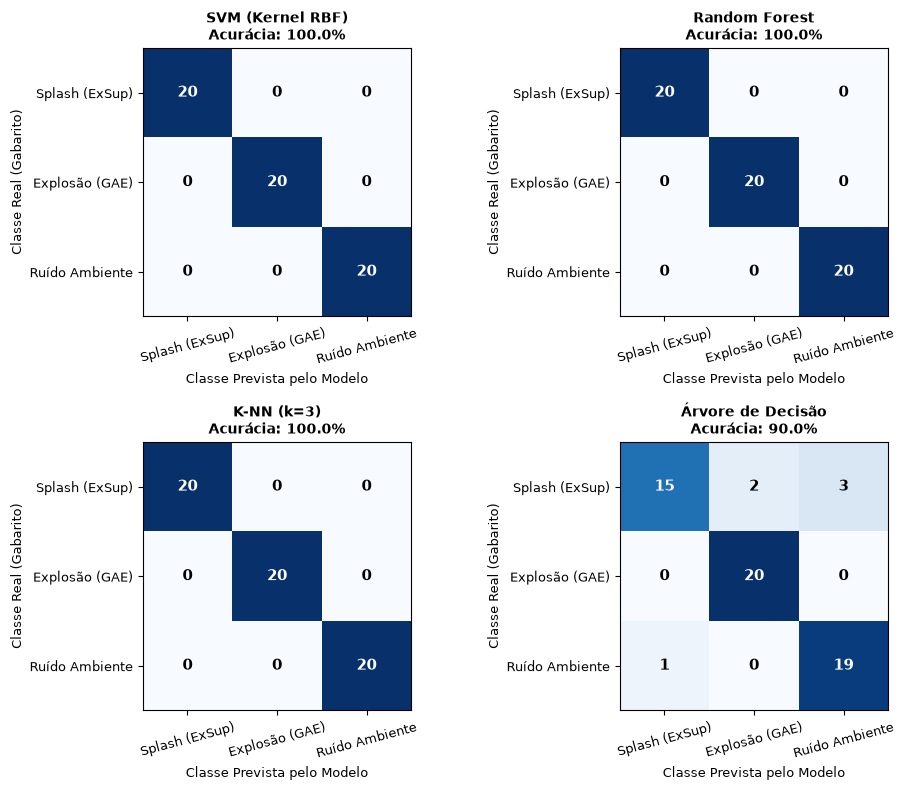

In [14]:
# CÉLULA 5: Visualização Gráfica das Matrizes de Confusão (Heatmaps)

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score

# 1. Definição dos rótulos das 3 classes operacionais da RVT
classes = ['Splash (ExSup)', 'Explosão (GAE)', 'Ruído Ambiente']

# 2. Criação da grade de gráficos 2x2 para os 4 classificadores
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

# 3. Loop para gerar o mapa de calor de cada modelo
for idx, (nome, modelo) in enumerate(modelos.items()):
    y_reais = []
    y_preditos = []
    
    # Validação cruzada LOOCV para coletar os resultados
    for treino_idx, teste_idx in loocv.split(X):
        modelo.fit(X[treino_idx], y[treino_idx])
        y_reais.append(y[teste_idx])
        y_preditos.append(modelo.predict(X[teste_idx]))
        
    cm = confusion_matrix(y_reais, y_preditos)
    acc = accuracy_score(y_reais, y_preditos)
    
    ax = axes[idx]
    im = ax.imshow(cm, cmap='Blues')  # Matriz em tons de azul
    
    # Inserção dos valores numéricos em cada célula
    for i in range(len(classes)):
        for j in range(len(classes)):
            cor = 'white' if cm[i, j] > cm.max() / 2 else 'black'
            ax.text(j, i, str(cm[i, j]), ha='center', va='center', color=cor, fontweight='bold', fontsize=11)
            
    # Configuração dos eixos e títulos
    ax.set_xticks(np.arange(len(classes)))
    ax.set_yticks(np.arange(len(classes)))
    ax.set_xticklabels(classes, rotation=15, fontsize=9)
    ax.set_yticklabels(classes, fontsize=9)
    ax.set_title(f'{nome}\nAcurácia: {acc * 100:.1f}%', fontsize=10, fontweight='bold')
    ax.set_xlabel('Classe Prevista pelo Modelo', fontsize=9)
    ax.set_ylabel('Classe Real (Gabarito)', fontsize=9)

plt.tight_layout()
plt.show()